In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
import pandas as pd
data = pd.read_excel("english_to_urdu_dataset - Copy.xlsx", header=None)

# EDA DATA ANYLYSIS

In [3]:
data.head()

,0,1
0,eng,urdu
1,the book of the generation of jesus christ th...,یسوع مسیح ابن داود ابن ابرہام کا نسب نامہ
2,abraham begat isaac and isaac begat jacob an...,ابراہام سے اضحاق پیدا ہوا اور اضحاق سے یعقوب پ...
3,and judas begat phares and zara of thamar and...,اور یہوداہ سے فارص اور زارح تمر سے پیدا ہوئے ا...
4,and aram begat aminadab and aminadab begat na...,اور رام سے عمینداب پیدا ہوا اور عمینداب سے نحس...


In [4]:
data[1].isna().sum()

np.int64(1)

In [9]:
data[1].fillna(data[1].mode()[0],inplace=True)

C:\Users\kkt\AppData\Local\Temp\ipykernel_16080\625045364.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[1].fillna(data[1].mode()[0],inplace=True)


In [11]:
data.duplicated().sum()

np.int64(9)

In [13]:
data.drop_duplicates(inplace=True)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9095 entries, 0 to 9103
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       9095 non-null   object
 1   1       9095 non-null   object
dtypes: object(2)
memory usage: 213.2+ KB


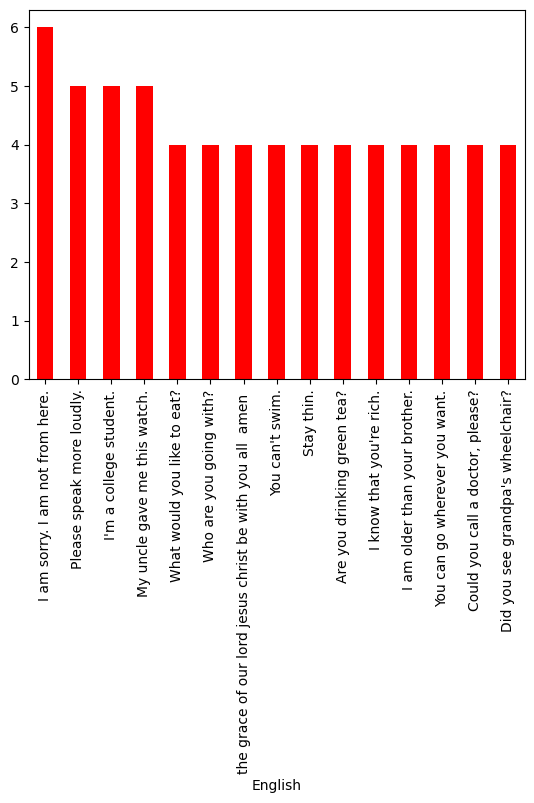

In [35]:
data["English"].value_counts().head(15).plot(kind = "bar",color = "r")
plt.show()

In [27]:
data.rename(columns={0:"English",1:"Urdu"},inplace=True)

# PREPROCESSING AND  CLEWNING

In [47]:
data["eng"]=data.English.str.lower().str.strip()

In [53]:
data.drop("eng",axis = 1,inplace=True)

In [57]:
data['English']=data.English.str.lower().str.strip()

In [63]:
data["Urdu"]=data.Urdu.str.lower().str.strip()

In [73]:
data["English"]=data["English"].fillna("")
data["Urdu"]=data["Urdu"].fillna("")

In [83]:
data.tail()

,English,Urdu
9099,children who are sixteen years old or younger ...,سولہ سال سے کم عمر کے بچے ٹھیٹر میں داخل نہیں ...
9100,she borrowed the book from him many years ago ...,اس نے اس سے یہ کتاب کئی سال پہلے ادھار لی تھی ...
9101,she asked him to not quit his job because they...,اس نے اسے اپنی نوکری چھوڑنے سے منع کیا کیونکہ ...
9102,tom would've liked to attend mary's party. unf...,ٹام میری کی پارٹی میں شامل تو ہونا چاہتا تھا م...
9103,"when you meet someone for the first time, be c...",جب تم پہلی دفعہ کسی سے ملو، اس بات کو مد نظر ر...


# TOKENIZER AND PADINNG

In [81]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [85]:
num_words = 10000

In [115]:
# Eng Tokenizer
eng_tok = Tokenizer(num_words=num_words)
eng_tok.fit_on_texts(data["English"])
eng_tok = eng_tok.texts_to_sequences(data["English"])
eng_sequence = pad_sequences(eng_tok,padding="post")

In [ ]:
# urdu Tokenizer
urdu_tok = Tokenizer(num_words=num_words)
urdu_tok.fit_on_texts(data["Urdu"])
urdu_tok = urdu_tok.texts_to_sequences(data["Urdu"])
urdu_sequence = pad_sequences(urdu_tok,padding="post")

In [127]:
print("English Token:",len(eng_tok)+1)
print("Urdu  Token:",len(urdu_tok)+1)

English Token: 9096
Urdu  Token: 9096


In [149]:
print("Urdu max len is :",max(len(a)for a in urdu_tok))
print("English max len is :",max(len(a) for a in eng_tok))

Urdu max len is : 84
English max len is : 68


# Prepare Encoder Aur Decoder Input

In [ ]:
## decoder_input = <start> main aik talib-e-ilm hoon
## decoder_target = main aik talib-e-ilm hoon <end>

In [174]:
import numpy as np
decoder_input = np.zeros_like(urdu_sequence) # saro ko 0 bana dia hai
decoder_input[:,1:] = urdu_sequence[:,:-1]
# decoder target = urdu sequence
decoder_input = urdu_sequence

In [13]:
import numpy as np
a = ['a','b','c','d','e','f',g]
np.zeros(5100)

array([0., 0., 0., ..., 0., 0., 0.], shape=(5100,))

# BUIld Encoder Aur Decoder

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
